# Trend deep dive

Deliverables 3-7: colour identity drift, pie-break tracking, rarity migration, type-line
crossover and the complexity proxy. Requires `mtg-analysis build` to have run.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import polars as pl

from mtg_analysis.analysis.color_drift import color_drift, keyword_vectors, plot_color_drift
from mtg_analysis.analysis.complexity import complexity_by_color, plot_complexity
from mtg_analysis.analysis.db import get_connection
from mtg_analysis.analysis.pie_break import pie_break, plot_pie_break
from mtg_analysis.analysis.rarity_migration import plot_rarity_migration, rarity_migration
from mtg_analysis.analysis.type_crossover import plot_type_crossover, type_crossover
from mtg_analysis.config import PeriodGroupConfig, load_config

config = load_config("../config/config.yaml")
# Grouping consecutive sets smooths the small-set noise these views are sensitive to.
con = get_connection("../" / config.paths.processed_dir,
                     PeriodGroupConfig(mode="rolling_sets", group_size=5))

## Colour identity drift (deliverable 3)

Each colour's keyword mix is normalized per period, then compared by cosine similarity to
the previous period and to the colour's all-time baseline. Lower means the toolbox moved.

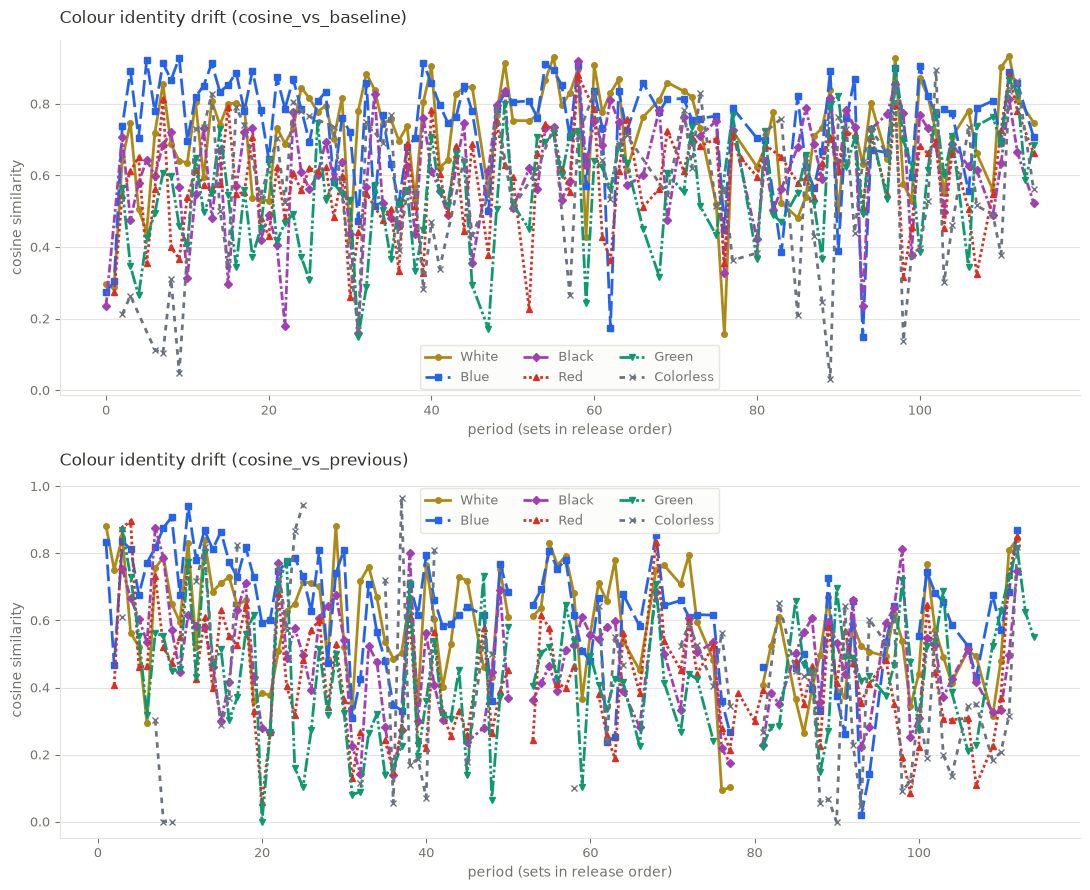

color,cosine_vs_baseline
str,f64
"""C""",0.55179
"""G""",0.556395
"""R""",0.584251
"""B""",0.610488
"""W""",0.713291
"""U""",0.739799


In [2]:
drift = color_drift(con)
fig, axes = plt.subplots(2, 1, figsize=(11, 9))
plot_color_drift(drift, metric="cosine_vs_baseline", ax=axes[0])
plot_color_drift(drift, metric="cosine_vs_previous", ax=axes[1])
fig.tight_layout()
plt.show()
drift.group_by("color").agg(pl.col("cosine_vs_baseline").mean()).sort("cosine_vs_baseline")

In [3]:
# The raw vectors, if you want to see which keywords drove a shift.
keyword_vectors(con).filter(pl.col("color") == "R").sort("freq", descending=True).head(10)

period,period_order,color,keyword,weight,total,freq
str,i64,str,str,f64,f64,f64
"""tgrn..pz2""",51,"""R""","""Double""",1.0,1.0,1.0
"""thob..tfra""",113,"""R""","""Haste""",2.0,3.0,0.666667
"""tbbd..tm19""",49,"""R""","""Flying""",4.0,7.5,0.533333
"""c14..gvl""",33,"""R""","""Haste""",2.0,4.0,0.5
"""tbrc..ybro""",78,"""R""","""Flying""",3.0,6.0,0.5
"""j25..tinr""",98,"""R""","""Trample""",3.0,7.0,0.428571
"""tzen..dde""",19,"""R""","""Kicker""",5.0,12.333333,0.405405
"""exo..wc98""",5,"""R""","""Buyback""",2.0,5.0,0.4
"""exo..wc98""",5,"""R""","""Enchant""",2.0,5.0,0.4


## Pie-break tracking (deliverable 4)

Finds the colour that historically owned a keyword, then tracks how much of it other
colours have taken.

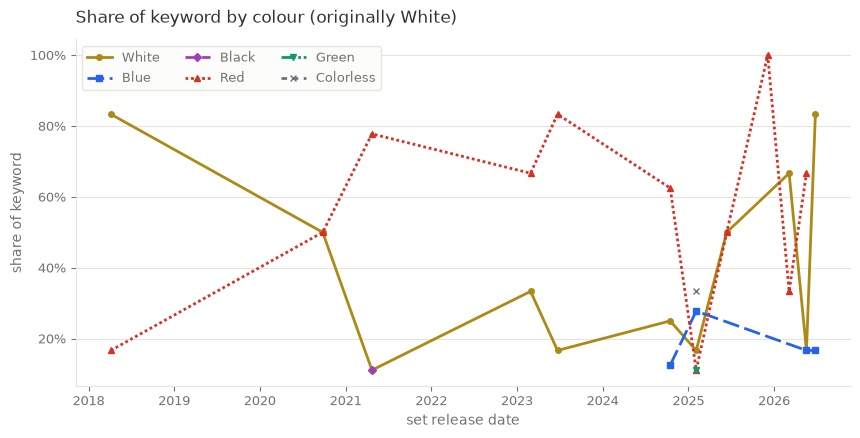

period,color,share,challenger_share
str,str,f64,f64
"""fic..aeoe""","""R""",0.5,0.5
"""fic..aeoe""","""W""",0.5,0.5
"""afic..ecl""","""R""",1.0,1.0
"""tmc..pf26""","""R""",0.333333,0.333333
"""tmc..pf26""","""W""",0.666667,0.333333
"""ysos..msc""","""R""",0.666667,0.833333
"""ysos..msc""","""U""",0.166667,0.833333
"""ysos..msc""","""W""",0.166667,0.833333
"""msh..hoc""","""U""",0.166667,0.166667


In [4]:
breaks = pie_break(con, "Double strike")
plot_pie_break(breaks)
plt.show()
breaks.select("period", "color", "share", "challenger_share").tail(10)

## Rarity migration (deliverable 5)

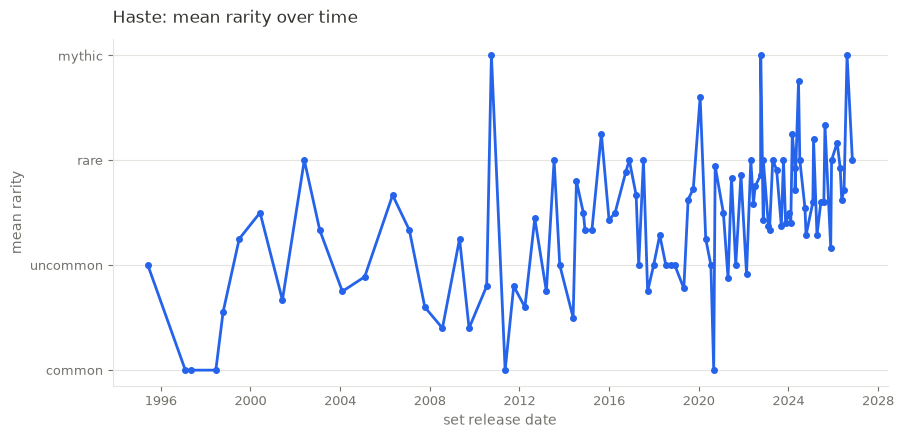

period,period_order,period_released_at,mean_rarity,n_appearances,keyword_weight,keyword,weighting
str,i64,date,f64,i64,f64,str,str
"""asos..tsos""",110,2026-04-24,1.928571,19,14.0,"""Haste""","""fractional"""
"""ysos..msc""",111,2026-05-19,1.625,22,16.0,"""Haste""","""fractional"""
"""msh..hoc""",112,2026-06-26,1.714286,20,14.0,"""Haste""","""fractional"""
"""thob..tfra""",113,2026-08-14,3.0,2,2.0,"""Haste""","""fractional"""
"""mbc..ttrk""",114,2026-11-09,2.0,1,1.0,"""Haste""","""fractional"""


In [5]:
rarity = rarity_migration(con, "Haste")
plot_rarity_migration(rarity)
plt.show()
rarity.tail()

## Type-line crossover (deliverable 6)

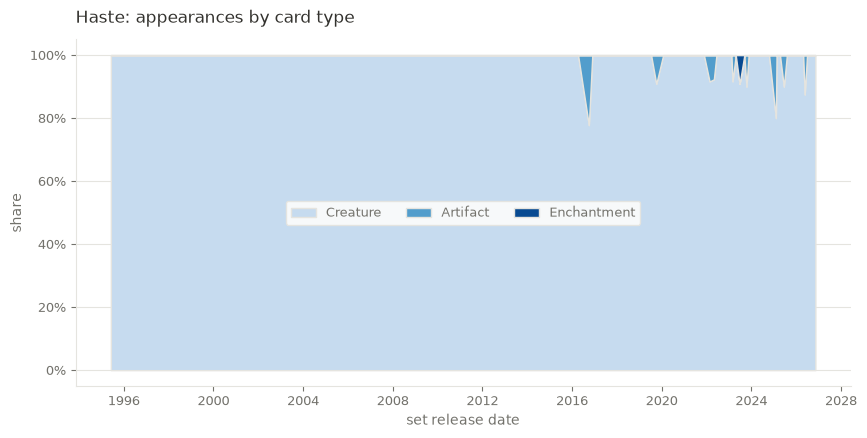

In [6]:
crossover = type_crossover(con, "Haste")
plot_type_crossover(crossover)
plt.show()

## Complexity proxy (deliverable 7)

Mean oracle text length and mean keyword count per card, weighted by colour.

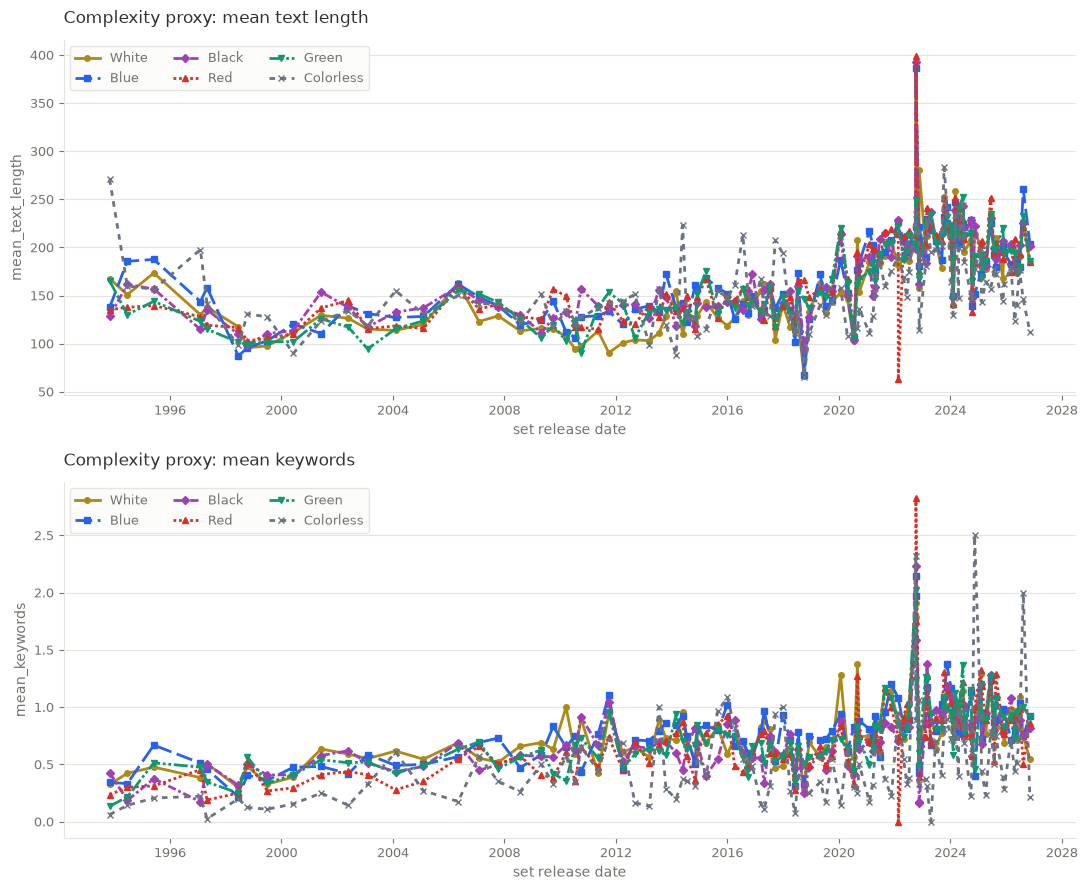

In [7]:
complexity = complexity_by_color(con)
fig, axes = plt.subplots(2, 1, figsize=(11, 9))
plot_complexity(complexity, metric="mean_text_length", ax=axes[0])
plot_complexity(complexity, metric="mean_keywords", ax=axes[1])
fig.tight_layout()
plt.show()